In [ ]:
##  BATCH PROCESS  BAD SNR lines 

###  --- what this code does  ---
###  takes in batch GIRAFFE/VLT fits file (and synthetic file): Load, Helio correct, normalise, regird (obs and synthetic), stack, normalise the stack, measure snr, save a 2 column .fits file  ###

####### INSTRUCTIONS  #########
#  RUN ALL -  just check settings in the FINAL cell  -  note that these settings overide the settin sin the fucntions (the cells that start with  def ....)

FIRST LOAD THE ONE SYNTHETIC  -  OUTSIDE THE BATHC PROCESSING 

In [2]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.convolution import convolve, Box1DKernel

In [ ]:
##  Synthetic load     NB.  ---- ASSUMES  CUNIT1 = nm   (so that we can convert to Angstroms)   ---- ASSUMED
###  TO DO     REGRID to same log-lambda grid    as the observed spectrum

syn_fits = "synthspec.fits"
c_kms = 299_792.458  # (not used here yet, but handy later)

with fits.open(syn_fits) as hdul:
    syn_flux = hdul[0].data.astype(float)
    syn_hdr  = hdul[0].header

crval = float(syn_hdr["CRVAL1"])          # nm
cdelt = float(syn_hdr["CDELT1"])          # nm / pix
npix  = int(syn_hdr["NAXIS1"])
crpix = float(syn_hdr.get("CRPIX1", 1.0)) # default assumes first pixel is reference    

# wavelength solution (nm), then convert to Å
syn_wave_nm = crval + (np.arange(npix) + 1 - crpix) * cdelt
syn_wave_A  = syn_wave_nm * 10.0

print(f"Synthetic template loaded: {syn_fits}")
print(f"CUNIT1={syn_hdr.get('CUNIT1')} (assumed nm → Å)")
print(f"λ range: {syn_wave_A[0]:.1f}–{syn_wave_A[-1]:.1f} Å, Npix={syn_wave_A.size}")
print(f"min / median / max flux: "f"{np.nanmin(syn_flux):.4f}, "f"{np.nanmedian(syn_flux):.4f}, " f"{np.nanmax(syn_flux):.4f}")

plt.figure(figsize=(12,4))
plt.plot(syn_wave_A, syn_flux, lw=0.6)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (synthetic)")
plt.title(f"Synthetic FITS template: {syn_fits}")
plt.tight_layout()
plt.show()

syn_store = {"Template_1": { "wavelength_A": syn_wave_A, "flux": syn_flux, "header": syn_hdr, "filename": syn_fits,}}

In [4]:
# AUTO detect lines on synthetic 
from scipy.signal import find_peaks
inv_flux = 1 - syn_flux   # invert spectrum so absorption lines become peaks
peaks, _ = find_peaks(inv_flux, height=0.013, distance=20)   # detect peaks deeper than ~1.3%
syn_lines = syn_wave_A[peaks]
syn_lines

array([8412.4 , 8417.85, 8426.5 , 8435.15, 8439.55, 8468.4 , 8498.  ,
       8502.3 , 8514.1 , 8527.1 , 8536.25, 8542.1 , 8556.8 , 8582.25,
       8598.6 , 8611.8 , 8621.6 , 8648.5 , 8662.1 , 8664.8 , 8674.75,
       8688.6 , 8699.45, 8710.35, 8713.1 , 8736.  , 8742.45, 8750.4 ,
       8751.9 , 8757.2 , 8763.95, 8773.85, 8790.45, 8793.35, 8804.65,
       8806.75, 8824.2 , 8838.45, 8862.65, 8866.95, 8868.4 ])

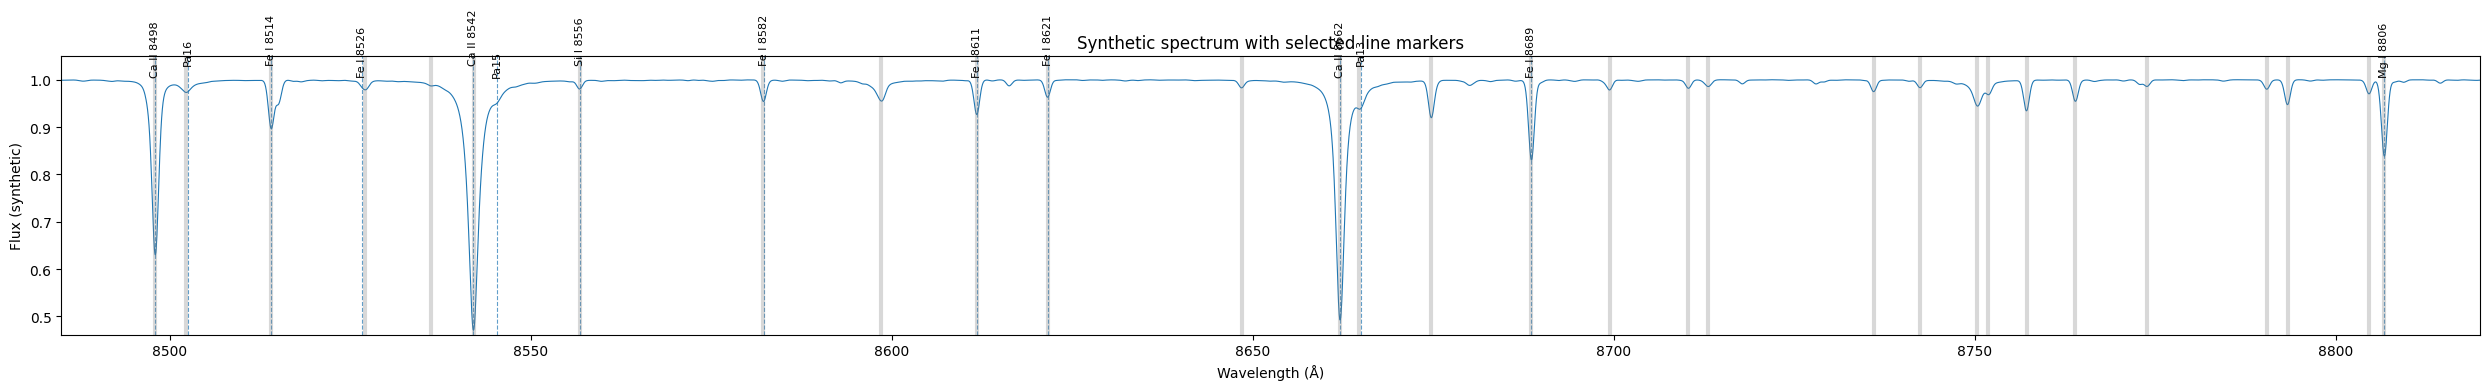

In [5]:
##  PLOT SYNTHETIC SPECTRUM WITH created and autodetected LINE MARKERS

line_marks = [("Ca II 8498", 8498.02), ("Ca II 8542", 8542.09), ("Ca II 8662", 8662.14), ("Pa16", 8502.49), ("Pa15", 8545.38), ("Pa13", 8665.02), ("Fe I 8468", 8468.41), ("Fe I 8514", 8514.07), ("Fe I 8526", 8526.67), ("Fe I 8582", 8582.27), ("Fe I 8611", 8611.81), ("Fe I 8621", 8621.60), ("Fe I 8689", 8688.63), ("Si I 8556", 8556.78), ("Mg I 8806", 8806.76)]

xlo, xhi = 8485, 8820
m = (syn_wave_A >= xlo) & (syn_wave_A <= xhi)

ymin = np.nanmin(syn_flux[m]) * 0.98                           
ymax = 1.05

plt.figure(figsize=(25,4))
plt.plot(syn_wave_A[m], syn_flux[m], lw=0.8)

for i, (label, lam0) in enumerate(line_marks):                                                      # plot the line markers only if they fall within the x-axis limits
    if xlo <= lam0 <= xhi:                                   
        plt.axvline(lam0, ls="--", lw=0.8, alpha=0.7)                                               
        ytext = 1.005 if i % 2 == 0 else 1.03                                                       
        plt.text(lam0, ytext, label, rotation=90, va="bottom", ha="center", fontsize=8)

# auto-detected lines
for lam in syn_lines:
    if xlo <= lam <= xhi:
        plt.axvline(lam, color="grey", alpha=0.3, lw=3)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (synthetic)")
plt.title("Synthetic spectrum with selected line markers")
plt.xlim(xlo, xhi)
plt.ylim(ymin, ymax)
plt.tight_layout()
plt.show()

ORDER for BAD individaul SNR:   (USED IN THIS workbook)
1) Load
2) Barycentric correct     ---    Note this is done without regridding which for the  Reticuulum GIRAFFE data case is fine beacuse the difference it makes is small over the small wavelenght rnage we are intereste din - CAT region 
3) Normalise
4) Regrid to common log λ grid  (observed and synthetic)   -   Needed before stack because thew barycentric correction 
5) Stack 
6) Re-Normalise the Stack
7) measure SNR
7) save stack as a .fits  (SNR in the header)
8) Measure RV from stacked spectrum
9) (optional but recommended) Shift stacked spectrum to stellar rest frame and save a “rest-frame” version too   ---- for abundances


ORDER for GOOD individual SNR:    (not used in this workbook)

1) Load
2) Barycentric correct
3) Normalise 
4) Regrid to a common log λ grid    (observed and synthetic onto same grid)
5) Measure stellar RV per exposure
6) Shift each exposure to stellar rest frame
(optional but often helpful) Re-normalise after shifting (tiny continuum differences can appear)
7) Stack
8) Save stacked FITS (rest-frame stack)

In [6]:
#1) LOAD
def load_star_spectra(star_index, base_dir, show_summary=False):                     # define a function called load_star_spectra, which takes a star_index, a base_dir, and an optional show_summary flag
    pattern = os.path.join(base_dir, f"{star_index}_c[0-9]_e*_hor5_srs.fits")        # pattern definition
    files = sorted(glob.glob(pattern))                                              # find all files matching the pattern and put them in a sorted list called  ---- files  -----

    if not files:
        raise FileNotFoundError(f"No files found matching: {pattern}")             # if nothing found  

    rows = []                                                                      # empty list
    spectra = {}                                                                   # empty dictionary to store spectra data
    exp_re = re.compile(r"_e(\d{2})_")                                             # pulls out the exposure number (e.g., e01, e02) from the filename for labeling purposes

    for fn in files:                                                                                                                            
        with fits.open(fn) as hdul:
            flux = hdul[0].data.astype(float)
            hdr  = hdul[0].header

        crval = float(hdr["CRVAL1"])
        cdelt = float(hdr["CDELT1"])
        n     = int(hdr["NAXIS1"])

        wave_nm = crval + cdelt * np.arange(n)
        wave_A  = wave_nm * 10.0
        hcorr   = float(hdr.get("HCORR", 0.0))

        m = exp_re.search(os.path.basename(fn))
        e_str = f"e{m.group(1)}" if m else None

        rows.append({
            "star_index": int(star_index),
            "e": e_str,
            "filename": os.path.basename(fn),
            "path": fn,
            "HCORR_km_s": hcorr,
            "NAXIS1_npix": n,
            "CRVAL1_nm": crval,
            "CDELT1_nm_per_pix": cdelt,
            "wave_start_nm": float(wave_nm[0]),
            "wave_end_nm": float(wave_nm[-1]),
            "wave_start_A": float(wave_A[0]),
            "wave_end_A": float(wave_A[-1]),
        })

        spectra[e_str] = {
            "filename": os.path.basename(fn),
            "path": fn,
            "flux": flux,
            "wave_A": wave_A,
            "wave_nm": wave_nm,
            "hdr": hdr,
            "HCORR_km_s": hcorr,
        }

    df = pd.DataFrame(rows).sort_values(["e", "filename"]).reset_index(drop=True)   # create a DataFrame, df,  from the rows list, sort it by exposure and filename, and reset the index

    if show_summary:
        display(df)
        print(f"Loaded {len(df)} files for star {star_index}: {', '.join(df['e'].dropna())}")
        print("Take going forward: the 'spectra' dictionary. x-axis is 'wave_A' (Angstroms), y-axis is 'flux'.")

    return spectra, df    #  this FUNCTION returns 1) the spectra dictionary and 2) df, the DataFrame summary of the loaded files

In [7]:
base_dir = "/home/scotdevlin/reticulum/reticulum"
star_index = 690286592

spectra, df = load_star_spectra(star_index, base_dir, show_summary=True)   # show_summary=True  overrides the default of False  foudn int he fucntion 

,star_index,e,filename,path,HCORR_km_s,NAXIS1_npix,CRVAL1_nm,CDELT1_nm_per_pix,wave_start_nm,wave_end_nm,wave_start_A,wave_end_A
0,690286592,e01,690286592_c1_e01_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,3.148345,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
1,690286592,e02,690286592_c1_e02_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,2.960406,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
2,690286592,e03,690286592_c1_e03_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,0.504392,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
3,690286592,e04,690286592_c1_e04_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,-0.371721,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
4,690286592,e05,690286592_c1_e05_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,-5.671308,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
5,690286592,e06,690286592_c1_e06_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,-5.873831,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
6,690286592,e07,690286592_c1_e07_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,4.422970,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
7,690286592,e08,690286592_c1_e08_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,3.702735,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
8,690286592,e09,690286592_c1_e09_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,-1.650766,10220,848.2,0.005,848.2,899.295,8482.0,8992.95
9,690286592,e10,690286592_c1_e10_hor5_srs.fits,/home/scotdevlin/reticulum/reticulum/690286592...,-4.265078,10220,848.2,0.005,848.2,899.295,8482.0,8992.95


Loaded 10 files for star 690286592: e01, e02, e03, e04, e05, e06, e07, e08, e09, e10
Take going forward: the 'spectra' dictionary. x-axis is 'wave_A' (Angstroms), y-axis is 'flux'.


In [8]:
# 2) HELIO CORRECT

def helio_correct(spectra, star_index=None, boxcar_width=3, plot_each=False, plot_overlay=False, overlay_xlim=None, overlay_ylim=None,):
    import matplotlib.pyplot as plt
    from astropy.convolution import convolve, Box1DKernel

    c_kms = 299_792.458

    # iterate over exposures already loaded
    for i, (e_str, s) in enumerate(sorted(spectra.items()), start=1):

        # start from stored native arrays (do NOT overwrite them)
        wave_A_native = s["wave_A"]
        flux_raw      = s["flux"]

        # heliocentric correction value already extracted in load step
        V_helio = float(s.get("HCORR_km_s", 0.0))  # km/s

        # optional smoothing (on flux only)
        if boxcar_width > 1:
            flux_smooth = convolve(flux_raw, Box1DKernel(boxcar_width))
        else:
            flux_smooth = flux_raw

        # heliocentric correction via wavelength shift
        wave_A_hcorr = wave_A_native * (1.0 + V_helio / c_kms)

        # add processed products to existing entry
        s["wave_A_hcorr"]  = wave_A_hcorr
        s["flux_smooth"]   = flux_smooth
        s["boxcar_width"]  = boxcar_width
        s["hcorr_applied"] = True

        print(
            f"Obs_{i:02d}: {s.get('filename','')} | "
            f"e={e_str} | HCORR={V_helio:.6f} km/s | npix={len(wave_A_native)}"
        )

        if plot_each:
            plt.figure(figsize=(12, 5))
            plt.plot(wave_A_hcorr, flux_smooth, label=f"Obs_{i:02d}")
            plt.xlabel("Wavelength (Å)")
            plt.ylabel("Flux")
            plt.title(f"GIRAFFE Spectrum (hcorr + smooth) {s.get('filename','')}")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    # optional overlay plot
    if plot_overlay:
        plt.figure(figsize=(20, 5))
        for i, (e_str, s) in enumerate(sorted(spectra.items()), start=1):
            plt.plot(s["wave_A_hcorr"], s["flux_smooth"], label=f"Obs_{i:02d}", alpha=0.8)

        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")

        if star_index is not None:
            plt.title(f"GIRAFFE Spectra, star:{star_index} (all exposures, heliocentric-corrected + smoothed)")
        else:
            plt.title("GIRAFFE Spectra (all exposures, heliocentric-corrected + smoothed)")

        plt.grid(True)
        plt.legend(ncol=2, fontsize=9)
        plt.tight_layout()

        if overlay_xlim is not None:
            plt.xlim(*overlay_xlim)
        if overlay_ylim is not None:
            plt.ylim(*overlay_ylim)

        plt.show()

    return spectra

In [ ]:
#  PLOT  helio corrected data
base_dir = "/home/scotdevlin/reticulum/reticulum"
star_index = 690759936

# Step 1: load
spectra, df = load_star_spectra(star_index, base_dir)

# Step 2: heliocentric correction + smoothing
boxcar_width = 3   # SETTINGS
spectra = helio_correct(spectra,star_index=star_index , boxcar_width=boxcar_width, plot_each=False, plot_overlay=True)   # show the overlay plot for checking


In [27]:
# 3) NORMALISE 

from scipy.interpolate import UnivariateSpline

def normalise_spectra(spectra, star_index=None, syn_lines=None, v_guess=240.0, wmin=8482.1, wmax=8720.0, q=60, bin_width=8.0, spline_k=3, spline_s=None, cat_half_width=10.0, line_marks_width=2.2,   # spline_s = None but the function allows you to specify a smoothing factor if desired (e.g., s=0 for exact interpolation, s>0 for some smoothing)
    syn_lines_width=1.0, spike_clip=98.0, plot_each=False, plot_xlim=None, plot_ylim=(0.2, 1.9), verbose=True,):
    c_kms = 299_792.458

    if syn_lines is None:
        syn_lines = np.array([], dtype=float)
    else:
        syn_lines = np.array(syn_lines, dtype=float)

    cat_lines = np.array([8498.02, 8542.09, 8662.14])   # vacuum Å
    cat_lines_obs = cat_lines * (1.0 + v_guess / c_kms)

    line_marks = [("Ca II 8498", 8498.02), ("Ca II 8542", 8542.09), ("Ca II 8662", 8662.14), ("Pa16", 8502.49), ("Pa15", 8545.38), ("Pa13", 8665.02), ("Fe I 8468", 8468.41), ("Fe I 8514", 8514.07), ("Fe I 8526", 8526.67), ("Fe I 8582", 8582.27), ("Fe I 8611", 8611.81), ("Fe I 8621", 8621.60),  ("Fe I 8689", 8688.63),  ("Si I 8556", 8556.78), ("Mg I 8806", 8806.76)]
    line_marks_obs = [(name, wl * (1.0 + v_guess / c_kms)) for name, wl in line_marks]
    syn_lines_obs = syn_lines * (1.0 + v_guess / c_kms)

    for e_str, s in sorted(spectra.items()):

        # choose wavelength + flux
        wave = s.get("wave_A_hcorr", s["wave_A"]).astype(float)
        flux = s.get("flux_smooth", s["flux"]).astype(float)

        # restrict to chosen wavelength window
        m = (wave >= wmin) & (wave <= wmax)
        lam = wave[m].copy()
        f   = flux[m].copy()

        if lam.size < 50:
            if verbose:
                print(f"{e_str}: skipped (too few pixels in window)")
            continue

        # rough normalization first
        med = np.nanmedian(f)
        if not np.isfinite(med) or med == 0:
            if verbose:
                print(f"{e_str}: skipped (bad median)")
            continue

        f_rough = f / med

        # build mask of regions to exclude from continuum selection
        mask_cont = np.ones_like(lam, dtype=bool)

        # mask CaT lines
        for lc in cat_lines_obs:
            mask_cont &= ~((lam > lc - cat_half_width) & (lam < lc + cat_half_width))

        # mask auto-detected synthetic lines
        for lc in syn_lines_obs:
            if wmin <= lc <= wmax:
                mask_cont &= ~((lam > lc - syn_lines_width) & (lam < lc + syn_lines_width))

        # mask named lines
        for _, lc in line_marks_obs:
            if wmin <= lc <= wmax:
                mask_cont &= ~((lam > lc - line_marks_width) & (lam < lc + line_marks_width))

        # robust anchor-per-bin continuum points
        anchor_lam = []
        anchor_flux = []
        top_mask_all = np.zeros_like(lam, dtype=bool)
        good_all = np.zeros_like(lam, dtype=bool)

        edges = np.arange(wmin, wmax + bin_width, bin_width)

        for lo, hi_bin in zip(edges[:-1], edges[1:]):                                         # 
            # pixels in this wavelength bin, after line masking but before spike clipping
            mb0 = (lam >= lo) & (lam < hi_bin) & mask_cont                                   # 
            if np.sum(mb0) < 10:
                continue

            # local spike clipping within this bin
            hi_b = np.nanpercentile(f_rough[mb0], spike_clip)
            mb = mb0 & (f_rough < hi_b)
            good_all |= mb

            if np.sum(mb) < 10:
                continue

            # select upper-flux pixels within this cleaned bin
            thr_b = np.nanpercentile(f_rough[mb], q)
            top = mb & (f_rough >= thr_b)

            if np.sum(top) < 3:
                continue

            top_mask_all |= top
            anchor_lam.append(np.nanmedian(lam[top]))
            anchor_flux.append(np.nanmedian(f_rough[top]))

        anchor_lam = np.array(anchor_lam, dtype=float)
        anchor_flux = np.array(anchor_flux, dtype=float)

        # continuum fit through anchors: spline instead of global polynomial
        if anchor_lam.size < 4:

            if np.sum(good_all) > 5:
                fill_val = np.nanmedian(f_rough[good_all])
            else:
                fill_val = 1.0

            cont_fit = fill_val * np.ones_like(f_rough)
            used_spline = False

        else:
            # sort anchors just in case
            order = np.argsort(anchor_lam)
            xk = anchor_lam[order]
            yk = anchor_flux[order]

            spline = UnivariateSpline(xk, yk, k=3, s=0.002 * len(xk))    

            if spline_s is None:
                spline_s_eff = 0.003 * len(xk)             # default smoothing factor if not specified, scaled with number of anchors   # s=0   -> interpolates exactly through anchors   # s>0   -> smooths a little
            else:
                spline_s_eff = spline_s

            spline = UnivariateSpline(xk, yk, k=spline_k, s=spline_s_eff)
            cont_fit = spline(lam)

            cont_fit = spline(lam)
            used_spline = True

        # guard against bad continuum values
        bad_cont = (~np.isfinite(cont_fit)) | (cont_fit <= 0)
        if np.any(bad_cont):
            if np.sum(good_all) > 5:
                fill_val = np.nanmedian(f_rough[good_all])
            else:
                fill_val = 1.0
            cont_fit[bad_cont] = fill_val

        # final normalized flux
        f_norm = f_rough / cont_fit

        # store results back into spectra
        s["lam_win"] = lam
        s["flux_win"] = f
        s["flux_rough"] = f_rough
        s["cont_fit"] = cont_fit
        s["flux_norm"] = f_norm
        s["anchor_lam"] = anchor_lam
        s["anchor_flux"] = anchor_flux
        s["top_mask_all"] = top_mask_all
        s["good_mask"] = good_all
        s["mask_cont"] = mask_cont
        s["norm_meta"] = {
            "method": "binned_upper_envelope_anchor_spline_with_CaT_mask",
            "wmin": wmin,
            "wmax": wmax,
            "q": q,
            "spline_k": spline_k,
            "spline_s": spline_s_eff,
            "bin_width_A": bin_width,
            "cat_half_width_A": cat_half_width,
            "line_marks_width_A": line_marks_width,
            "syn_lines_width_A": syn_lines_width,
            "spike_clip_percentile": spike_clip,
            "v_guess_km_s": v_guess,
            "used_spline": used_spline,
            "n_anchor_points": int(anchor_lam.size),
        }

        # plot diagnostics
        if plot_each:
            plt.figure(figsize=(25, 4))

            plt.plot(lam, f, lw=0.7, alpha=0.25, label="Before (raw)")
            plt.plot(lam, f_rough, lw=0.8, alpha=0.9, label="Rough norm (÷median)")

            clipped = mask_cont & ~good_all
            if np.any(clipped):
                plt.scatter(
                    lam[clipped], f_rough[clipped],
                    s=10, alpha=0.5, label="Spike-clipped", color="red"
                )

            if np.any(top_mask_all):
                plt.scatter(
                    lam[top_mask_all], f_rough[top_mask_all],
                    s=10, alpha=0.55, marker="o",
                    label="Top pixels used for anchors",
                    color="cyan", edgecolor="none", zorder=4
                )

            if anchor_lam.size > 0:
                plt.scatter(
                    anchor_lam, anchor_flux,
                    s=40, alpha=0.95, marker="o",
                    label="Continuum anchors (used)",
                    color="limegreen", edgecolor="k", zorder=5
                )

            plt.plot(lam, cont_fit, lw=1.2, alpha=0.95, label="Continuum fit")
            plt.plot(lam, f_norm, lw=0.9, alpha=0.9, label="After (continuum norm)")

            for lc in cat_lines_obs:
                if wmin <= lc <= wmax:
                    plt.axvspan(lc - cat_half_width, lc + cat_half_width, alpha=0.12)

            for _, lc in line_marks_obs:
                if wmin <= lc <= wmax:
                    plt.axvspan(
                        lc - line_marks_width, lc + line_marks_width,
                        alpha=0.08, color="orange"
                    )

            for lc in syn_lines_obs:
                if wmin <= lc <= wmax:
                    plt.axvspan(
                        lc - syn_lines_width, lc + syn_lines_width,
                        alpha=0.06, color="grey"
                    )

            for name, wl in line_marks_obs:
                if wmin <= wl <= wmax:
                    plt.axvline(wl, color="grey", lw=0.6, alpha=0.5)
                    plt.text(
                        wl, 1.28, name, rotation=90, fontsize=7,
                        ha="center", va="bottom", alpha=0.7
                    )

            for lam_syn in syn_lines_obs:
                if wmin <= lam_syn <= wmax:
                    plt.axvline(lam_syn, color="grey", alpha=0.20, lw=1.5)

            plt.axhline(1.0, color="k", lw=0.6, alpha=0.5)
            plt.xlabel("Wavelength (Å)")
            plt.ylabel("Flux")

            if star_index is not None:
                plt.title(
                    f"star {star_index} obs {e_str} — anchor-per-bin continuum norm "
                    f"(q={q}, spline {spline_k}, s={spline_s}), bin_width={bin_width}, spike_clip={spike_clip} | anchors={anchor_lam.size}"
                )
            else:
                plt.title(
                    f"obs {e_str} — anchor-per-bin continuum norm "
                    f"(q={q}, spline {spline_k}, s={spline_s}), bin_width={bin_width}, spike_clip={spike_clip} | anchors={anchor_lam.size}"
                )

            if plot_xlim is not None:
                plt.xlim(*plot_xlim)
            else:
                plt.xlim(wmin, wmax)

            if plot_ylim is not None:
                plt.ylim(*plot_ylim)

            plt.legend(ncol=2, fontsize=9)
            plt.tight_layout()
            plt.show()

    return spectra

In [ ]:
# plot notmalisation diagnostic for star_index
v_guess = 240.0; wmin = 8482.1; wmax = 8720.0; q = 60; bin_width = 16.0; cat_half_width = 10.0; line_marks_width = 2.2; syn_lines_width = 1.0; spike_clip = 98.0; c_kms = 299_792.458; ymin = 0.2; ymax = 1.3   # SETTINGS
spline_k = 3        # spline degree (k=3 is cubic spline, k=1 would be linear, etc.)
spline_s = 0.0005     #  s = 0  meams spline goes EXACTLY through anchors, larger s adhers less well to anchors but gives smoother continuum.  

spectra = normalise_spectra(spectra, star_index=star_index, syn_lines=syn_lines, v_guess=v_guess, wmin=wmin, wmax=wmax, q=q, spline_k=spline_k, spline_s=spline_s, bin_width=bin_width, cat_half_width=cat_half_width,
                             line_marks_width=line_marks_width, syn_lines_width=syn_lines_width, spike_clip=spike_clip, plot_each=True)   # turn ON for single-star diagnostics

In [12]:
# 4) REGRID

def regrid_spectra(spectra, syn_store, star_index=None, template_key="Template_1", wmin=8482.1, wmax=8720.0, plot_overlay=False, plot_xlim=None, plot_ylim=(0.2, 1.3), verbose=True,):   #  
    c_kms = 299_792.458

    # --------------------------------------------------
    # Estimate native pixel scale in km/s from observed spectra
    # --------------------------------------------------
    dv_list = []

    for e_str, s in spectra.items():
        if "wave_A_hcorr" not in s:
            continue

        wave_A_hcorr = s["wave_A_hcorr"]
        dlam_A = np.nanmedian(np.diff(wave_A_hcorr))
        lam0_A = np.nanmedian(wave_A_hcorr)
        dv_list.append(c_kms * (dlam_A / lam0_A))

    if len(dv_list) == 0:
        raise ValueError("No spectra contain 'wave_A_hcorr'; cannot estimate dv_native.")

    dv_native = np.nanmedian(dv_list)

    if verbose:
        print("dv_native:", dv_native)
        print(
            "We take this as the pixel scale for the log-lambda grid - "
            f"each pixel represents {dv_native:.6f} km/s"
        )

    dloglam = np.log1p(dv_native / c_kms)

    # --------------------------------------------------
    # Define overlap region across all observed exposures
    # using lam_win so it matches the normalisation window
    # --------------------------------------------------
    lam_min_obs = max(np.nanmin(s["lam_win"]) for s in spectra.values() if "lam_win" in s)
    lam_max_obs = min(np.nanmax(s["lam_win"]) for s in spectra.values() if "lam_win" in s)

    lam_min = max(lam_min_obs, wmin)
    lam_max = min(lam_max_obs, wmax)

    if not np.isfinite(lam_min) or not np.isfinite(lam_max) or lam_max <= lam_min:
        raise ValueError("Invalid overlap region for regridding.")

    loglam_grid = np.arange(np.log(lam_min), np.log(lam_max), dloglam)
    lam_grid = np.exp(loglam_grid)

    if lam_grid.size < 2:
        raise ValueError("Common log-lambda grid has too few pixels.")

    if verbose:
        print(
            f"log-λ grid: dv={dv_native:.3f} km/s, "
            f"Npix={lam_grid.size}, range={lam_grid[0]:.2f}–{lam_grid[-1]:.2f} Å"
        )

    # --------------------------------------------------
    # Regrid observed spectra onto lam_grid
    # --------------------------------------------------
    n_obs = 0

    for e_str, s in spectra.items():
        if "lam_win" not in s or "flux_norm" not in s:
            continue

        lam = s["lam_win"]
        f = s["flux_norm"]

        f_rg = np.interp(lam_grid, lam, f, left=np.nan, right=np.nan)

        s["lam_log"] = lam_grid
        s["flux_norm_log"] = f_rg

        n_obs += 1

    if n_obs == 0:
        raise ValueError("No observed spectra were regridded; missing 'lam_win' or 'flux_norm'.")

    # --------------------------------------------------
    # Regrid synthetic template onto lam_grid
    # --------------------------------------------------
    if template_key not in syn_store:
        raise KeyError(f"Template '{template_key}' not found in syn_store.")

    syn = syn_store[template_key]
    lam_s = syn["wavelength_A"].astype(float)
    f_s = syn["flux"].astype(float)

    m_syn = (lam_s >= lam_min) & (lam_s <= lam_max)
    lam_s = lam_s[m_syn]
    f_s = f_s[m_syn]

    if lam_s.size < 2:
        raise ValueError(f"Synthetic template '{template_key}' has too few pixels in overlap region.")

    syn_rg = np.interp(lam_grid, lam_s, f_s, left=np.nan, right=np.nan)

    syn_store[template_key]["lam_log"] = lam_grid
    syn_store[template_key]["flux_log"] = syn_rg

    # --------------------------------------------------
    # Optional sanity overlay plot
    # --------------------------------------------------
    if plot_overlay:
        plt.figure(figsize=(20, 4))

        for e_str, s in sorted(spectra.items()):
            if "flux_norm_log" not in s:
                continue
            plt.plot(
                s["lam_log"],
                s["flux_norm_log"],
                lw=0.8,
                alpha=0.6,
                label=f"Observed (regridded) obs {e_str}"
            )

        plt.plot(lam_grid, syn_rg, lw=1.2, color="k", alpha=0.9, label="Synthetic (regridded)")
        plt.axhline(1.0, color="k", lw=0.6, alpha=0.4)
        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux (continuum-normalised)")

        if star_index is not None:
            plt.title(f"Star {star_index} — Sanity check: regridded to common log-λ grid (Nobs={n_obs})")
        else:
            plt.title(f"Sanity check: regridded to common log-λ grid (Nobs={n_obs})")

        if plot_xlim is not None:
            plt.xlim(*plot_xlim)
        else:
            plt.xlim(lam_min, lam_max)

        if plot_ylim is not None:
            # plt.ylim(*plot_ylim)
            plt.ylim(0.8, 1.1)

        plt.legend(ncol=2, fontsize=9)
        plt.tight_layout()
        plt.show()

    return spectra, syn_store, lam_grid, dv_native

In [ ]:
# PLOT regridding diagnostic for star_index
spectra, syn_store, lam_grid, dv_native = regrid_spectra(           #  LHS is the output of the function, RHS is the function call with the arguments
    spectra, syn_store,  star_index=star_index,  template_key="Template_1",  wmin=8480,  wmax=8720,  plot_overlay=True,  verbose=True,)

In [14]:
# 5) STACK

def stack_spectra(
    spectra,
    lam_grid=None,
    star_index=None,
    clip_sigma=2.0,
    clip_iters=5,
    min_good=3,
    do_median=True,
    plot_stack=False,
    plot_n_good=False,
    plot_xlim=None,
    # plot_ylim=(0.1, 1.3),
    plot_ylim=(0.8, 1.3),
    verbose=True,
):
    # -----------------------------
    # Prepare array of regridded, normalised spectra for stacking
    # -----------------------------
    exp_keys = [k for k, s in spectra.items() if "flux_norm_log" in s]

    if len(exp_keys) == 0:
        raise ValueError("No spectra contain 'flux_norm_log'; cannot stack.")

    F = np.array([spectra[k]["flux_norm_log"] for k in exp_keys])

    if lam_grid is None:
        lam_grid = next(s["lam_log"] for s in spectra.values() if "flux_norm_log" in s)

    if verbose:
        print(f"Nexp={F.shape[0]}, Npix={F.shape[1]}")

    # -----------------------------
    # Sigma-clipped mean (per pixel)
    # -----------------------------
    mask = np.isfinite(F)

    for it in range(clip_iters):
        mu = np.nanmean(np.where(mask, F, np.nan), axis=0)
        sig = np.nanstd(np.where(mask, F, np.nan), axis=0)
        sig = np.where(sig == 0, np.nan, sig)

        resid = (F - mu[None, :]) / sig[None, :]
        new_mask = mask & (np.abs(resid) <= clip_sigma)

        if np.array_equal(new_mask, mask):
            break

        mask = new_mask

    n_good = np.sum(mask, axis=0)

    stack_clipmean = np.nanmean(np.where(mask, F, np.nan), axis=0)
    stack_clipmean[n_good < min_good] = np.nan

    # optional median stack
    stack_median = np.nanmedian(F, axis=0) if do_median else None

    # -----------------------------
    # Store results
    # -----------------------------
    stack_store = {
        "lam_log": lam_grid,
        "flux_stack_clipmean": stack_clipmean,
        "n_good": n_good,
        "exp_keys": exp_keys,
        "clip_sigma": clip_sigma,
        "clip_iters": clip_iters,
        "min_good": min_good,
    }

    if stack_median is not None:
        stack_store["flux_stack_median"] = stack_median

    if verbose:
        print("Done. Stored in stack_store['flux_stack_clipmean'] (and median if enabled).")

    # -----------------------------
    # Plot: individuals + stack(s)
    # -----------------------------
    if plot_stack:
        plt.figure(figsize=(20, 4))

        for e in exp_keys:
            plt.plot(lam_grid, spectra[e]["flux_norm_log"], lw=0.6, alpha=0.4)

        plt.plot(lam_grid, stack_clipmean, lw=2.0, alpha=0.95, label="Stack: sigma-clipped mean")

        if stack_median is not None:
            plt.plot(
                lam_grid,
                stack_median,
                lw=1.2,
                alpha=1.0,
                linestyle="--",
                label="Stack: median"
            )

        plt.axhline(1.0, color="k", lw=0.6, alpha=0.4)
        plt.ylabel("Flux (continuum-normalised)")

        if star_index is not None:
            plt.title(f"Star {star_index} Stacked observed spectrum (N={len(exp_keys)})")
        else:
            plt.title(f"Stacked observed spectrum (N={len(exp_keys)})")

        if plot_xlim is not None:
            plt.xlim(*plot_xlim)
        else:
            plt.xlim(lam_grid[0], lam_grid[-1])

        if plot_ylim is not None:
            plt.ylim(*plot_ylim)

        plt.legend()
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Plot: how many exposures contributed after clipping
    # -----------------------------
    if plot_n_good:
        plt.figure(figsize=(20, 2.5))
        plt.plot(lam_grid, n_good, lw=0.8)
        plt.xlabel("Wavelength (Å)")
        plt.ylabel("N good")
        plt.title("Number of contributing exposures per pixel after clipping")

        if plot_xlim is not None:
            plt.xlim(*plot_xlim)
        else:
            plt.xlim(lam_grid[0], lam_grid[-1])

        plt.tight_layout()
        plt.show()

    return stack_store

In [ ]:
# PLOT stack diagnostic for star_index
stack_store = stack_spectra(spectra, lam_grid=lam_grid,  star_index=star_index, clip_sigma=2.0, clip_iters=5, min_good=3, do_median=True, plot_stack=True, plot_n_good=True, verbose=True,)  # LHS is the output, RHS is the function call with arguments

In [16]:
# 6) RENORMALISE STACK

def renormalise_stack( stack_store, star_index=None, v_guess=240.0,  cat_half_width=10.0, plot=True, plot_xlim=None, verbose=True):

    c_kms = 299_792.458

    lam_grid = stack_store["lam_log"]
    stack_clipmean = stack_store["flux_stack_clipmean"]
    stack_median = stack_store.get("flux_stack_median", None)

    cat_lines = np.array([8498.02, 8542.09, 8662.14])
    cat_lines_shifted = cat_lines * (1.0 + v_guess / c_kms)

    # --------------------------------
    # Build mask of good continuum pixels
    # --------------------------------
    stack_good = np.isfinite(stack_clipmean)

    for lc in cat_lines_shifted:
        stack_good &= ~((lam_grid > lc - cat_half_width) &
                        (lam_grid < lc + cat_half_width))

    # --------------------------------
    # Compute continuum scale
    # --------------------------------
    scale = np.nanmedian(stack_clipmean[stack_good])

    if np.isfinite(scale) and scale > 0:
        stack_clipmean_renorm = stack_clipmean / scale
        stack_median_renorm = (
            stack_median / scale if stack_median is not None else None
        )
    else:
        stack_clipmean_renorm = stack_clipmean.copy()
        stack_median_renorm = (
            stack_median.copy() if stack_median is not None else None
        )

    # --------------------------------
    # Store results
    # --------------------------------
    stack_store["flux_stack_clipmean_renorm"] = stack_clipmean_renorm
    stack_store["scale_clipmean"] = scale
    stack_store["stack_good_mask"] = stack_good

    if stack_median_renorm is not None:
        stack_store["flux_stack_median_renorm"] = stack_median_renorm

    if verbose:
        print(f"clipmean renorm scale = {scale:.6f}")

    # --------------------------------
    # Plot diagnostics
    # --------------------------------
    if plot:

        plt.figure(figsize=(25,4))

        plt.plot(lam_grid, stack_clipmean, lw=1.2, alpha=0.7, label="Stack: sigma-clipped mean (original)")

        plt.plot( lam_grid, stack_clipmean_renorm, lw=2.0, alpha=0.95, label="Stack: sigma-clipped mean (renorm)")

        if stack_median is not None:
            plt.plot(  lam_grid, stack_median, lw=1.1, alpha=0.8, linestyle="--", label="Stack: median (original)")

        if stack_median_renorm is not None:
            plt.plot( lam_grid, stack_median_renorm, lw=1.8, alpha=0.95, linestyle="--", label="Stack: median (renorm)")

        for lc in cat_lines_shifted:
            plt.axvspan(  lc - cat_half_width, lc + cat_half_width, alpha=0.10, color="grey" )

        plt.axhline(1.0, color="k", lw=0.6, alpha=0.4)

        plt.ylabel("Flux (continuum-normalised)")
        plt.xlabel("Wavelength (Å)")

        if star_index is not None:
            plt.title(f"Star {star_index} — post-stack renormalisation")
        else:
            plt.title("Post-stack renormalisation")

        if plot_xlim is not None:
            plt.xlim(*plot_xlim)
        else:
            plt.xlim(lam_grid[0], lam_grid[-1])

        plt.ylim(0.3, 1.4)

        plt.legend()
        plt.tight_layout()
        plt.show()

        # Residual plot
        plt.figure(figsize=(20,3))

        plt.axhline(0.0, color="k", lw=0.6, alpha=0.4)

        plt.plot(lam_grid, stack_clipmean_renorm - 1.0, lw=1.2, label="clipmean renorm - 1")

        if stack_median_renorm is not None:
            plt.plot(lam_grid, stack_median_renorm - 1.0, lw=1.2, linestyle="--", label="median renorm - 1")

        for lc in cat_lines_shifted:
            plt.axvspan( lc - cat_half_width,  lc + cat_half_width,  alpha=0.10,  color="grey")

        plt.ylabel("Residual")
        plt.xlabel("Wavelength (Å)")
        plt.title("Renormalised stacked spectrum residual relative to 1.0")

        if plot_xlim is not None:
            plt.xlim(*plot_xlim)
        else:
            plt.xlim(lam_grid[0], lam_grid[-1])

        plt.ylim(-0.1, 0.1)

        plt.legend()
        plt.tight_layout()
        plt.show()

    return stack_store

In [ ]:
# PLOT renormalisation diagnostic for star_index
stack_store = renormalise_stack(stack_store, star_index=star_index, v_guess=v_guess, cat_half_width=cat_half_width, plot=True)

In [18]:
# 7) SNR ESTIMATION

def estimate_snr_for_stack(spectra, stack_store, star_index=None, cont_windows=None, clip_sigma=3.0, clip_iters=5, min_pix=20, verbose=True):
    """
    Estimate:
      1) per-exposure continuum SNR from spectra[e]['flux_norm_log']
      2) stacked-spectrum continuum SNR for clipmean and median stacks

    Stores results in:
      - spectra[e]['snr_pix']
      - stack_store['snr_store']

    Returns:
      stack_store, snr_store
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # -----------------------------
    # defaults
    # -----------------------------
    if cont_windows is None:
        cont_windows = [ (8516.0, 8518.0), (8527.0, 8531.0), (8569.0, 8578.0),  (8608.0, 8615.0),  (8635.0, 8648.0),  (8691.0, 8692.0)]

    lam_grid = stack_store["lam_log"]
    stack_clipmean = stack_store["flux_stack_clipmean_renorm"]
    stack_median = stack_store.get("flux_stack_median_renorm", None)
    exp_keys = stack_store.get("exp_keys", [])

    # -----------------------------
    # robust helpers
    # -----------------------------
    def robust_sigma_mad(x):
        x = np.asarray(x)
        x = x[np.isfinite(x)]
        if x.size < 10:
            return np.nan
        med = np.nanmedian(x)
        mad = np.nanmedian(np.abs(x - med))
        return 1.4826 * mad

    def sigma_clip_mask(y, nsig=3.0, iters=5, min_pts=10):
        y = np.asarray(y)
        m = np.isfinite(y)

        if m.sum() < min_pts:
            return m

        for _ in range(iters):
            yy = y[m]
            mu = np.nanmedian(yy)
            sig = robust_sigma_mad(yy)

            if not np.isfinite(sig) or sig <= 0:
                break

            new_m = m & (np.abs(y - mu) <= nsig * sig)

            if new_m.sum() < min_pts or np.array_equal(new_m, m):
                m = new_m
                break

            m = new_m

        return m

    def estimate_sigma_and_snr(lam, flux, windows, clip_sigma=3.0, clip_iters=5, min_pix=20):
        sigmas = []
        npixs = []

        lam = np.asarray(lam)
        flux = np.asarray(flux)

        for (a, b) in windows:
            mw = (lam >= a) & (lam <= b) & np.isfinite(flux)

            if mw.sum() < min_pix:
                sigmas.append(np.nan)
                npixs.append(int(mw.sum()))
                continue

            y = flux[mw]
            keep = sigma_clip_mask(y, nsig=clip_sigma, iters=clip_iters, min_pts=10)
            sig = robust_sigma_mad(y[keep])

            sigmas.append(sig)
            npixs.append(int(np.sum(keep)))

        sigma_flux = np.nanmedian(sigmas)
        snr_pix = (1.0 / sigma_flux) if np.isfinite(sigma_flux) and sigma_flux > 0 else np.nan

        return sigma_flux, snr_pix, sigmas, npixs

    # -----------------------------
    # 1) per-exposure SNR
    # -----------------------------
    snr_rows = []

    for e in exp_keys:
        if e not in spectra:
            continue
        if "lam_log" not in spectra[e] or "flux_norm_log" not in spectra[e]:
            continue

        lam = spectra[e]["lam_log"]
        flx = spectra[e]["flux_norm_log"]

        sigma_flux, snr_pix, sigs, nps = estimate_sigma_and_snr(
            lam, flx, cont_windows,
            clip_sigma=clip_sigma,
            clip_iters=clip_iters,
            min_pix=min_pix,
        )

        snr_rows.append((e, snr_pix, sigma_flux, np.nanmedian(nps)))

        spectra[e]["sigma_flux_snrwin"] = sigma_flux
        spectra[e]["snr_pix_snrwin"] = snr_pix

    snr_vals = np.array([r[1] for r in snr_rows], dtype=float)

    exp_snr_mean = np.nanmean(snr_vals) if snr_vals.size else np.nan
    exp_snr_median = np.nanmedian(snr_vals) if snr_vals.size else np.nan
    exp_snr_min = np.nanmin(snr_vals) if np.isfinite(snr_vals).any() else np.nan
    exp_snr_max = np.nanmax(snr_vals) if np.isfinite(snr_vals).any() else np.nan
    n_exp_snr = int(np.sum(np.isfinite(snr_vals)))

    # -----------------------------
    # 2) stacked SNR: sigma-clipped mean
    # -----------------------------
    sigma_mean, snr_mean, sigs_mean, nps_mean = estimate_sigma_and_snr(
        lam_grid, stack_clipmean, cont_windows,
        clip_sigma=clip_sigma,
        clip_iters=clip_iters,
        min_pix=min_pix,
    )

    # -----------------------------
    # 3) stacked SNR: median
    # -----------------------------
    if stack_median is not None:
        sigma_median, snr_median, sigs_median, nps_median = estimate_sigma_and_snr(
            lam_grid, stack_median, cont_windows,
            clip_sigma=clip_sigma,
            clip_iters=clip_iters,
            min_pix=min_pix,
        )
    else:
        sigma_median, snr_median = np.nan, np.nan
        sigs_median, nps_median = [], []

    # -----------------------------
    # store in stack_store
    # -----------------------------
    snr_store = {
        "cont_windows": cont_windows,
        "snr_rows": snr_rows,
        "exp_snr_mean": exp_snr_mean,
        "exp_snr_median": exp_snr_median,
        "exp_snr_min": exp_snr_min,
        "exp_snr_max": exp_snr_max,
        "n_exp_snr": n_exp_snr,
        "sigma_mean_stack": sigma_mean,
        "snr_mean_stack": snr_mean,
        "sigma_median_stack": sigma_median,
        "snr_median_stack": snr_median,
        "mean_window_sigmas": sigs_mean,
        "mean_window_npixels": nps_mean,
        "median_window_sigmas": sigs_median,
        "median_window_npixels": nps_median,
    }

    stack_store["snr_store"] = snr_store

    # -----------------------------
    # optional printout
    # -----------------------------
    if verbose:
        snr_rows_sorted = sorted(
            snr_rows,
            key=lambda t: np.nan_to_num(t[1], nan=-1),
            reverse=True
        )

        print("Per-exposure continuum SNR estimates (SNR ~ 1 / sigma_flux):")
        print(f"{'exp':>8s}  {'SNR_pix':>8s}  {'sigma_flux':>10s}  {'Npix(win_med)':>13s}")
        for e, snr_pix, sigma_flux, nmed in snr_rows_sorted:
            print(f"{e:>8s}  {snr_pix:8.1f}  {sigma_flux:10.5f}  {int(nmed):13d}")

        print(f"\nSummary over exposures (N={len(snr_vals)}):")
        print(f"  mean   SNR_pix = {exp_snr_mean:.1f}")
        print(f"  median SNR_pix = {exp_snr_median:.1f}")
        print(f"  min/max SNR_pix = {exp_snr_min:.1f} / {exp_snr_max:.1f}")

        print("\nStacked (sigma-clipped mean) continuum SNR estimate:")
        for (w, sig, n) in zip(cont_windows, sigs_mean, nps_mean):
            print(f"  {w[0]:7.1f}-{w[1]:7.1f} Å : sigma={sig:8.5f}   N={n}")
        print(f"  adopted sigma_flux = {sigma_mean:.5f}")
        print(f"  mean-stack SNR ~ {snr_mean:.1f}")

        if np.isfinite(snr_median):
            print(f"\nMedian-stack SNR ~ {snr_median:.1f}")

        # quick histogram
        if np.isfinite(snr_vals).any():
            plt.figure(figsize=(7, 3.5))
            plt.hist(snr_vals[np.isfinite(snr_vals)], bins=15)
            plt.xlabel("Per-exposure continuum SNR per pixel (≈ 1/sigma)")
            plt.ylabel("Count")
            if star_index is not None:
                plt.title(f"Star {star_index}: per-exposure SNR distribution")
            else:
                plt.title("Per-exposure SNR distribution")
            plt.tight_layout()
            plt.show()

        # -----------------------------
        # stacked spectrum diagnostic plot
        # -----------------------------
        plt.figure(figsize=(20, 6))
        plt.plot(lam_grid, stack_clipmean, lw=0.8, color="k",
                 label="Stack (sigma-clipped mean)")

        xlo, xhi = lam_grid[0], lam_grid[-1]

        # noise windows
        for i, (a, b) in enumerate(cont_windows):
            if b < xlo or a > xhi:
                continue
            plt.axvspan(a, b, alpha=0.35, color="lightblue",
                        label="noise window" if i == 0 else None)

        # sigma band
        if np.isfinite(sigma_mean):
            plt.axhline(1.0, lw=0.6, alpha=0.6, color="k")
            plt.axhline(1.0 + sigma_mean, lw=0.6, alpha=0.4, color="k", linestyle="--")
            plt.axhline(1.0 - sigma_mean, lw=0.6, alpha=0.4, color="k", linestyle="--")

        plt.xlim(xlo, xhi)
        plt.ylim(0.78, 1.06)

        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux (continuum-normalised)")

        if star_index is not None:
            plt.title(f"Star {star_index}: stacked spectrum noise windows + +/- sigma band (SNR~{snr_mean:.1f})")
        else:
            plt.title(f"Stacked spectrum noise windows + +/- sigma band (SNR~{snr_mean:.1f})")

        plt.legend(loc="upper right", fontsize=8)
        plt.tight_layout()
        plt.show()

    return stack_store, snr_store

In [ ]:
# PLOT / PRINT SNR diagnostic for one star
stack_store, snr_store = estimate_snr_for_stack(
    spectra,
    stack_store,
    star_index=star_index,
    verbose=True,
)

In [20]:
# 8) SAVE TO FITS

def save_stack_to_fits(stack_store, syn_store, star_index, output_dir, template_key="Template_1", dv_native=None, save_median=True, verbose=True):

    os.makedirs(output_dir, exist_ok=True)

    lam_grid = stack_store["lam_log"]
    stack_clipmean = stack_store["flux_stack_clipmean_renorm"]
    stack_median = stack_store.get("flux_stack_median_renorm", None)

    exp_keys = stack_store.get("exp_keys", [])
    n_exp = len(exp_keys)

    snr_store = stack_store.get("snr_store", {})

    # -----------------------------
    # Mean stack
    # -----------------------------
    output_file_mean = os.path.join(output_dir, f"{star_index}_meanstacked.fits")

    cols_mean = [
        fits.Column(name="WAVELENGTH", format="D", array=lam_grid),
        fits.Column(name="FLUX", format="D", array=stack_clipmean),
    ]

    hdu_mean = fits.BinTableHDU.from_columns(cols_mean)
    hdu_mean.name = "STACK"

    hdr = hdu_mean.header
    hdr["STARID"] = str(star_index)
    hdr["STACK"] = "SIGCLIP_MEAN"
    hdr["NEXP"] = n_exp
    hdr["GRIDTYPE"] = "LOG-LAM"

    if dv_native is not None:
        hdr["DVPIX"] = float(dv_native)

    if "clip_sigma" in stack_store:
        hdr["CLIPSIG"] = stack_store["clip_sigma"]

    if "clip_iters" in stack_store:
        hdr["CLIPITR"] = stack_store["clip_iters"]

    if "min_good" in stack_store:
        hdr["MINGOOD"] = stack_store["min_good"]

    # SNR keywords if available
    if snr_store:
        hdr["SNRMETH"] = ("MADWIN", "SNR from MAD in continuum windows")
        hdr["SNRWINS"] = (len(snr_store.get("cont_windows", [])), "Number of continuum windows")
        hdr["SNRNEXP"] = (int(snr_store.get("n_exp_snr", 0)), "N exposures with valid exp-SNR")
        hdr["SNRXMEAN"] = (float(snr_store.get("exp_snr_mean", np.nan)), "Mean per-exposure SNR/pix")
        hdr["SNRXMED"] = (float(snr_store.get("exp_snr_median", np.nan)), "Median per-exposure SNR/pix")
        hdr["SNRXMIN"] = (float(snr_store.get("exp_snr_min", np.nan)), "Min per-exposure SNR/pix")
        hdr["SNRXMAX"] = (float(snr_store.get("exp_snr_max", np.nan)), "Max per-exposure SNR/pix")
        hdr["SIGSTACK"] = (float(snr_store.get("sigma_mean_stack", np.nan)), "Mean-stack sigma_flux")
        hdr["SNRSTACK"] = (float(snr_store.get("snr_mean_stack", np.nan)), "Mean-stack SNR per pixel")

    hdu_mean.writeto(output_file_mean, overwrite=True)

    if verbose:
        print(f"Saved mean stack: {output_file_mean}")

    # -----------------------------
    # Median stack
    # -----------------------------
    if save_median and stack_median is not None:

        output_file_median = os.path.join(output_dir, f"{star_index}_medianstacked.fits")

        cols_median = [
            fits.Column(name="WAVELENGTH", format="D", array=lam_grid),
            fits.Column(name="FLUX", format="D", array=stack_median),
        ]

        hdu_median = fits.BinTableHDU.from_columns(cols_median)
        hdu_median.name = "STACK"

        hdr = hdu_median.header
        hdr["STARID"] = str(star_index)
        hdr["STACK"] = "MEDIAN"
        hdr["NEXP"] = n_exp
        hdr["GRIDTYPE"] = "LOG-LAM"

        if dv_native is not None:
            hdr["DVPIX"] = float(dv_native)

        if snr_store:
            hdr["SNRMETH"] = ("MADWIN", "SNR from MAD in continuum windows")
            hdr["SNRWINS"] = (len(snr_store.get("cont_windows", [])), "Number of continuum windows")
            hdr["SNRNEXP"] = (int(snr_store.get("n_exp_snr", 0)), "N exposures with valid exp-SNR")
            hdr["SNRXMEAN"] = (float(snr_store.get("exp_snr_mean", np.nan)), "Mean per-exposure SNR/pix")
            hdr["SNRXMED"] = (float(snr_store.get("exp_snr_median", np.nan)), "Median per-exposure SNR/pix")
            hdr["SNRXMIN"] = (float(snr_store.get("exp_snr_min", np.nan)), "Min per-exposure SNR/pix")
            hdr["SNRXMAX"] = (float(snr_store.get("exp_snr_max", np.nan)), "Max per-exposure SNR/pix")
            hdr["SIGSTACK"] = (float(snr_store.get("sigma_median_stack", np.nan)), "Median-stack sigma_flux")
            hdr["SNRSTACK"] = (float(snr_store.get("snr_median_stack", np.nan)), "Median-stack SNR per pixel")

        hdu_median.writeto(output_file_median, overwrite=True)

        if verbose:
            print(f"Saved median stack: {output_file_median}")

    # -----------------------------
    # Save regridded synthetic
    # -----------------------------
    if template_key in syn_store:

        syn = syn_store[template_key]

        output_file_syn = os.path.join(
            output_dir,
            f"{star_index}_synthetic_regridded.fits"
        )

        cols_syn = [
            fits.Column(name="WAVELENGTH", format="D", array=syn["lam_log"]),
            fits.Column(name="FLUX", format="D", array=syn["flux_log"]),
        ]

        hdu_syn = fits.BinTableHDU.from_columns(cols_syn)
        hdu_syn.name = "STACK"

        hdr = hdu_syn.header
        hdr["SRCFILE"] = os.path.basename(str(syn.get("filename", "synthetic")))
        hdr["STARID"] = str(star_index)
        hdr["GRIDTYPE"] = "LOG-LAM"

        if dv_native is not None:
            hdr["DVPIX"] = float(dv_native)

        hdu_syn.writeto(output_file_syn, overwrite=True)

        if verbose:
            print(f"Saved regridded synthetic: {output_file_syn}")

In [21]:
# TEST save to fits for star_index

# settings 
base_dir = "/home/scotdevlin/reticulum/reticulum" 
output_dir = base_dir

# run function
save_stack_to_fits(stack_store, syn_store,  star_index,  output_dir, dv_native=dv_native,)

Saved mean stack: /home/scotdevlin/reticulum/reticulum/690759936_meanstacked.fits
Saved median stack: /home/scotdevlin/reticulum/reticulum/690759936_medianstacked.fits
Saved regridded synthetic: /home/scotdevlin/reticulum/reticulum/690759936_synthetic_regridded.fits


In [22]:
# COUNT ALL STARS in the folder /home/scotdevlin/reticulum/reticulum
import glob, os

data_dir = "/home/scotdevlin/reticulum/reticulum"

star_list = sorted({
    os.path.basename(f).split("_")[0]
    for f in glob.glob(os.path.join(data_dir, "*_c[0-9]_e*_hor5_srs.fits"))    #  [0-9]  means any single digit, so it will match c1, c2, c3, etc.
})

print("Found stars:", star_list)
len(star_list)

Found stars: ['689426496', '689523264', '689532672', '689543616', '689638528', '689704192', '689743104', '689763584', '689768448', '689776000', '689778624', '689874048', '689880192', '689891264', '689894528', '689933440', '689954048', '689979584', '689987520', '690006912', '690016128', '690034432', '690036096', '690050944', '690059648', '690063744', '690089024', '690091648', '690092736', '690121344', '690122880', '690148416', '690152064', '690158144', '690169856', '690190848', '690204480', '690210816', '690214400', '690239936', '690242432', '690246528', '690256064', '690258816', '690274944', '690279296', '690282880', '690286592', '690290304', '690290432', '690321216', '690321792', '690336128', '690336896', '690339136', '690366784', '690377280', '690387968', '690402880', '690407808', '690409281', '690410880', '690411840', '690419456', '690446784', '690450240', '690450304', '690458560', '690462592', '690466816', '690470912', '690489920', '690502912', '690512064', '690512384', '690514880'

137

In [ ]:
# RUN ALL for ALL STARs

#  CHOOSE diagnostic stars for printing plots  ---   all other plots supressed
diagnostic_stars = {'691377216', '690462592'}  # Example star indices   NB:  cna put multiple stars liekthis in:     #  diagnostic_stars = {'690759936', '690869184'}  # Example star indices



# ---------------------------
# PIPELINE SETTINGS   ---  NB these setting override defaults in the functions.  --- 
# ---------------------------
base_dir = "/home/scotdevlin/reticulum/reticulum"
output_dir = base_dir

boxcar_width = 3

# normalization
v_guess = 240.0
wmin, wmax = 8482.1, 8720.0
q = 60
bin_width = 16.0
cat_half_width = 10.0
line_marks_width = 2.2
syn_lines_width = 1.0
spike_clip = 98.5
spline_k = 3        # spline degree (k=3 is cubic spline, k=1 would be linear, etc.)
spline_s = 0.03     #  s = 0  meams spline goes EXACTLY through anchors, larger s adhers less well to anchors but gives smoother continuum.  

# stacking
clip_sigma = 2.0
clip_iters = 5
min_good = 3
do_median = True

# master controls
show_summary = False
verbose = False
plot_helio_each = False
plot_helio_overlay = False
plot_norm_each = False
plot_regrid_overlay = False
plot_stack = False
plot_n_good = False
plot_renorm = False

# ------------------



for star_index in star_list:

    diag = star_index in diagnostic_stars

    print(f"\n===== Processing star {star_index} =====")

    # 1) LOAD
    spectra, df = load_star_spectra(star_index,   base_dir,  show_summary=diag,)

    # 2) HELIO CORRECT
    spectra = helio_correct(spectra,  star_index=star_index,  boxcar_width=boxcar_width,  plot_each=False,  plot_overlay=diag,)

    # 3) NORMALISE
    spectra = normalise_spectra(spectra, star_index=star_index, syn_lines=syn_lines, v_guess=v_guess, wmin=wmin, wmax=wmax, q=q, spline_k=spline_k, spline_s=spline_s, bin_width=bin_width, cat_half_width=cat_half_width, 
                                line_marks_width=line_marks_width, syn_lines_width=syn_lines_width, spike_clip=spike_clip, plot_each=diag, verbose=diag)
    
    # 4) REGRID   (observed + synthetic onto common log-lambda grid)  --- nB.  THE SYNTHETIC TEMPLATE IS ALSO REGRIDDED HERE
    spectra, syn_store, lam_grid, dv_native = regrid_spectra(spectra,  syn_store, star_index=star_index, template_key="Template_1", wmin=wmin, wmax=wmax, plot_overlay=diag, verbose=diag,)

    # 5) STACK
    stack_store = stack_spectra(spectra, lam_grid=lam_grid, star_index=star_index, clip_sigma=clip_sigma, clip_iters=clip_iters, min_good=min_good, do_median=do_median, plot_stack=diag, plot_n_good=diag, verbose=diag)

    # 6) RENORMALISE STACK
    stack_store = renormalise_stack(stack_store,  star_index=star_index, v_guess=v_guess, cat_half_width=cat_half_width, plot=diag, verbose=diag,)

    # 7) SNR
    stack_store, snr_store = estimate_snr_for_stack(spectra, stack_store, star_index=star_index, verbose=diag,)

    # 8) SAVE TO FITS
    save_stack_to_fits(stack_store, syn_store, star_index, output_dir, dv_native=dv_native, verbose=diag,)